# The TW Project

## Stage 1: Finetune a YOLO26s on LLVIP dataset

### Data preparation

In [ ]:
"""Download the LLVIP dataset"""

import os


LLVIP_DATASET_URL = "https://drive.google.com/uc?id=1VTlT3Y7e1h-Zsne4zahjx5q0TK2ClMVv"

def download_llvip_dataset():
    import gdown
    gdown.download(
        url=LLVIP_DATASET_URL,
        output="LLVIP.zip",
    )

if not os.path.exists("LLVIP.zip"):
    print("Dataset not downloaded, now downloading")
    download_llvip_dataset()
else:
    import hashlib

    with open("LLVIP.zip", "rb") as f:
        file_hash = hashlib.md5()
        while chunk := f.read(8192):
            file_hash.update(chunk)
    if file_hash.hexdigest() != "e64affb4b0b50e1772ff6f67da873bf6":
        print("Download dataset again due to hash mismatch")
        download_llvip_dataset()

if not os.path.exists("datasets"):
    os.makedirs("datasets")

if not os.path.exists("datasets/LLVIP"):
    import zipfile
    
    with zipfile.ZipFile("LLVIP.zip", "r") as zip_ref:
        zip_ref.extractall("datasets")

In [ ]:
"""Convert VOC format to YOLO format."""

import shutil
import globox as gx
from pathlib import Path


LLVIP_DATASET_PATH = Path("datasets/LLVIP").resolve()

IMG_DIR = LLVIP_DATASET_PATH / "infrared"
LABELS_DIR = LLVIP_DATASET_PATH / "labels"

TRAIN_LABELS_DIR = LABELS_DIR / "train"
VAL_LABELS_DIR = LABELS_DIR / "test"

LABELS_DIR.mkdir(exist_ok=True)
TRAIN_LABELS_DIR.mkdir(exist_ok=True)
VAL_LABELS_DIR.mkdir(exist_ok=True)

llvip = gx.AnnotationSet.from_pascal_voc(LLVIP_DATASET_PATH / "Annotations")
llvip.show_stats()
llvip.save_yolo_v7(
    save_dir=LABELS_DIR,
    label_to_id={"person": 0},
)

IMG_DIR = IMG_DIR.rename(LLVIP_DATASET_PATH / "images")
TRAIN_SPLIT_PATH = IMG_DIR / "train"
VAL_SPLIT_PATH = IMG_DIR / "test"

for split_img_dir, labels_out_dir in [
    (TRAIN_SPLIT_PATH, TRAIN_LABELS_DIR),
    (VAL_SPLIT_PATH, VAL_LABELS_DIR),
]:
    for img_path in split_img_dir.iterdir():
        label_file = LABELS_DIR / f"{img_path.stem}.txt"
        if label_file.exists():
            shutil.move(str(label_file), labels_out_dir / label_file.name)
        else:
            print(f"WARNING: no label for {img_path.name}")

yaml_path = LLVIP_DATASET_PATH / "llvip.yaml"
yaml_path.write_text(f"""train: {TRAIN_SPLIT_PATH}
val: {VAL_SPLIT_PATH}
nc: 1
names: ['person']
""")

129

### Tuning and training

In [ ]:
from pathlib import Path
from ultralytics.models.yolo.detect import DetectionTrainer


class CustomSaveTrainer(DetectionTrainer):
    """Trainer that saves the best model based on recall instead of default fitness."""

    def validate(self):
        """Override fitness to use recall for best model selection."""
        metrics, fitness = super().validate()
        if metrics is not None:
            recall  = metrics.get("metrics/recall(B)", 0.0)
            map50   = metrics.get("metrics/mAP50(B)", 0.0)
            map5095 = metrics.get("metrics/mAP50-95(B)", 0.0)

            fitness = (0.60 * recall) + (0.30 * map5095) + (0.10 * map50)

            if self.best_fitness is None or fitness > self.best_fitness:
                self.best_fitness = fitness
        return metrics, fitness

(null): No such file or directory
(null): No such file or directory


In [2]:
"""Train YOLO26n"""

from ultralytics import YOLO


yaml_path = Path("datasets/LLVIP/llvip.yaml").resolve()

model = YOLO("yolo26n.pt")
model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=64,
    optimizer="MuSGD",
    lr0=0.0054,
    lrf=0.0495,
    momentum=0.947,
    weight_decay=0.00064,
    warmup_epochs=0.98,
    name="llvip_yolo26n",
    cache='disk',
    patience=20,
    trainer=CustomSaveTrainer,
    exist_ok=True,
    device="cuda:0",
    workers=16,
    close_mosaic=15,
    # Augmentation
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.2,
    degrees=0.0,
    translate=0.1,
    scale=0.4,
    shear=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.2,
    mixup=0.0,
    erasing=0.2,
)

In [1]:
"""Resume from a crash"""

from ultralytics import YOLO


model = YOLO("runs/detect/llvip_yolo26n/weights/last.pt")
model.train(resume=True)

(null): No such file or directory


New https://pypi.org/project/ultralytics/8.4.52 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.46 🚀 Python-3.13.13 torch-2.12.0+rocm7.2 CUDA:0 (AMD Radeon Graphics, 16368MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/w/tw_project/datasets/LLVIP/llvip.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0054, lrf=0.0495, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/llvip_yolo26n/weights/last

(null): No such file or directory


YOLO26n summary: 260 layers, 2,504,190 parameters, 2,504,190 gradients, 5.8 GFLOPs

Transferred 708/708 items from pretrained weights
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.3±0.0 ms, read: 353.8±80.1 MB/s, size: 107.0 KB)
train: Scanning /home/w/tw_project/datasets/LLVIP/labels/train.cache... 12025 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12025/12025 2.7Git/s 0.0s
train: Caching images (44.0GB Disk): 100% ━━━━━━━━━━━━ 12025/12025 75.1Kit/s 0.2s.3s
val: Fast image access ✅ (ping: 2.6±1.2 ms, read: 41.7±9.6 MB/s, size: 86.3 KB)
val: Scanning /home/w/tw_project/datasets/LLVIP/labels/test.cache... 3463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3463/3463 154.5Mit/s 0.0s
val: Caching images (12.7GB Disk): 100% ━━━━━━━━━━━━ 3463/3463 17.6Kit/s 0.2s3s
optimizer: MuSGD(lr=0.0054, momentum=0.947) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.00064), 126 bias(decay=0.0)
Plotting labels 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7efe74f77150>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

### Model inference and eval

In [24]:
"""Run val"""

from ultralytics import YOLO

model = YOLO("runs/detect/llvip_yolo26n/weights/best.pt")
metrics = model.val(
    name="llvip_val_results",
    data="datasets/LLVIP/llvip.yaml",
    batch=128,
    imgsz=640,
    device="cuda:0",
    exist_ok=True,
    save_txt=True,
    save_conf=True,
)

Ultralytics 8.4.46 🚀 Python-3.13.13 torch-2.12.0+rocm7.2 CUDA:0 (AMD Radeon Graphics, 16368MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 351.9±154.4 MB/s, size: 85.5 KB)
val: Scanning /home/w/tw_project/datasets/LLVIP/labels/test.cache... 3463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3463/3463 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 1.1it/s 26.5s0.7ss
                   all       3463       8302      0.944      0.897      0.954      0.641
Speed: 0.3ms preprocess, 1.3ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/w/tw_project/runs/detect/llvip_val_results


## Stage 2: LLM

In [1]:
"""Filter boxes by confidence threshold. ALWAYS RUN"""

import globox as gx


CONFIDENCE_THRESHOLD = 0.281 # Best F1 score

preds = gx.AnnotationSet.from_yolo_v7(
    folder="runs/detect/llvip_val_results/labels",
    image_folder="datasets/LLVIP/images/test",
)

for annotation in preds:
    annotation.boxes = [box for box in annotation.boxes if box.confidence >= CONFIDENCE_THRESHOLD]

preds.show_stats()

          Database Stats          
┏━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ Label         ┃ Images ┃ Boxes ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0             │   3436 │  7883 │
│ <empty_image> │     26 │     0 │
├───────────────┼────────┼───────┤
│ Total         │   3462 │  7883 │
└───────────────┴────────┴───────┘

### Annotate images

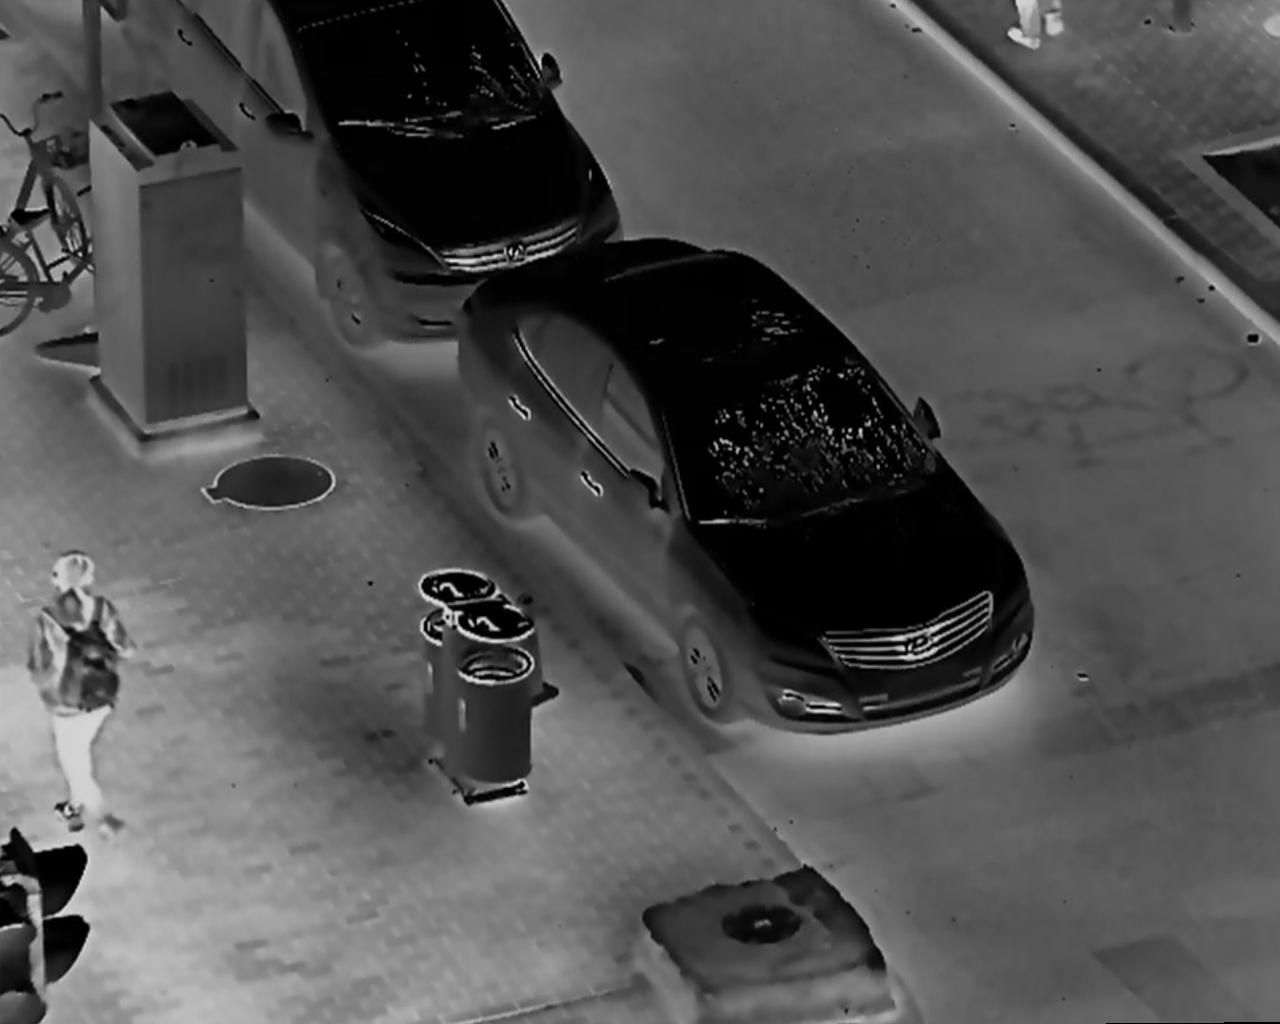

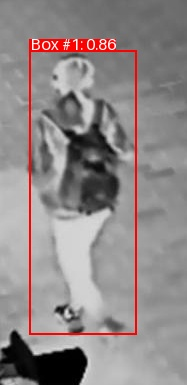

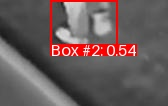

In [32]:
"""Annotate and crop images"""

from pathlib import Path
import globox as gx
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display


IMG_SRC_DIR = Path("datasets/LLVIP/images/test").resolve()
IMG_OUT_DIR = Path("datasets/LLVIP/annotated").resolve()

IMG_OUT_DIR.mkdir(exist_ok=True)

CROP_PADDING = 50  # pixels

def annotate_image(annotation: gx.Annotation, img_path: Path):
    img_out_dir = IMG_OUT_DIR / img_path.stem
    img_out_dir.mkdir(exist_ok=True)

    orig_img = Image.open(img_path)

    # Save original as 0.jpg
    orig_img.save(img_out_dir / "0.jpg", quality=95)

    font = ImageFont.load_default(16)

    for i, box in enumerate(annotation.boxes, start=1):
        line = f"Box #{i}: {box.confidence:.2f}"

        img = orig_img.copy()
        img_draw = ImageDraw.Draw(img)
        img_draw.rectangle([box.xmin, box.ymin, box.xmax, box.ymax], outline="red", width=2)

        if box.ymin - font.size < 0:
            text_position = (box.xmin, box.ymax - font.size)
        else:
            text_position = (box.xmin, box.ymin - font.size)
        text_box = img_draw.textbbox(text_position, line, font=font)
        img_draw.rectangle(text_box, fill="red")
        img_draw.text(text_position, line, fill="white", font=font)

        # Crop with padding
        x1 = max(0, box.xmin - CROP_PADDING)
        y1 = max(0, box.ymin - CROP_PADDING)
        x2 = min(img.width, box.xmax + CROP_PADDING)
        y2 = min(img.height, box.ymax + CROP_PADDING)

        cropped = img.crop((x1, y1, x2, y2))
        cropped.save(img_out_dir / f"{i}.jpg", quality=95)

# Test
annotation = preds.get("230381.jpg")
if annotation and annotation.boxes:
    img_path = IMG_SRC_DIR / annotation.image_id
    annotate_image(annotation, img_path)

    img_out_dir = IMG_OUT_DIR / img_path.stem
    for img_file in sorted(img_out_dir.glob("*.jpg")):
        display(Image.open(img_file))

# Process all
# for annotation in preds:
#     if annotation.boxes:
#         img_path = IMG_SRC_DIR / annotation.image_id
#         annotate_image(annotation, img_path)

### LLM prompting

vllm launch command:
```bash
vllm serve Qwen/Qwen3.5-4B \
--dtype float16 \
--kv-cache-dtype float16 \
--max-model-len 6144 \
--gpu-memory-utilization 0.97 \
--data-parallel-size 2 \
--enable-prefix-caching \
--mm-encoder-tp-mode data \
--max-num-seqs 16 \
--max-num-batched-tokens 8192 \
--reasoning-parser qwen3 \
--reasoning-config '{"reasoning_start_str": "<think>", "reasoning_end_str": "... Time is running out, I have to give the final verdict directly now.</think>"}'
```

In [13]:
"""Test single response"""

import litellm
import asyncio
import base64
import os
from pathlib import Path
from pydantic import BaseModel
from typing import Any, Literal


os.environ["OPENAI_API_KEY"] = "sk-lmao"

IMG_SRC_DIR = Path("datasets/LLVIP/images/test").resolve()
IMG_OUT_DIR = Path("datasets/LLVIP/annotated").resolve()

SYSTEM_PROMPT = """You are a quality-control assistant for an infrared (thermal) pedestrian detector.

You will receive:
1. An infrared image of a scene without any annotations.
2. Cropped infrared images of each detected box, with a red bounding box drawn on it.
3. A metadata block listing each box's number and detector confidence score.

Your task is to inspect each box individually and decide whether it is a valid detection.

Rules:
- The images are low-resolution infrared: humans appear as bright (hot) blobs against a darker background.
- A VALID box tightly encloses a human body or a clear portion of one (head, torso, legs).
- A FALSE_POSITIVE box covers background clutter, vehicle heat signatures, reflections, artifacts,
  or a region with no discernible human shape.
- Use UNCERTAIN when image quality or occlusion makes a confident call difficult.

DO NOT skip any boxes present in the metadata. The number of boxes in the output MUST match the number of boxes in the metadata.
"""

class BoxVerdict(BaseModel):
    id: int
    verdict: Literal["VALID", "FALSE_POSITIVE", "UNCERTAIN"]

class BoxesList(BaseModel):
    boxes: list[BoxVerdict]


def _encode_image_b64(path: Path) -> str:
    return base64.b64encode(path.read_bytes()).decode()

def _prepare_context(b64_images: list[str], pred: gx.Annotation) -> list[dict[str, Any]]:
    image_blocks = [
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{b64}",
                "detail": "high",
            },
        }
        for b64 in b64_images
    ]

    metadata_lines = [f"Box #{i}: confidence {box.confidence:.2f}" for i, box in enumerate(pred.boxes, start=1)]
    metadata = "\n".join(metadata_lines)

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": [
                *image_blocks,
                {
                    "type": "text",
                    "text": (
                        f"Metadata for this scene:\n{metadata}\n\n"
                        "Validate every box listed above. "
                        "Respond ONLY with the JSON object described in your instructions."
                    ),
                },
            ],
        },
    ]

async def llm_inferece(folder: Path) -> dict[str, Any]:
    pred = preds.get(f"{folder.name}.jpg")
    if not pred:
        raise ValueError(f"How could this pass through the filter? {folder.name}.jpg")

    img_paths = sorted(folder.glob("*.jpg"))
    b64_images = await asyncio.gather(
        *[asyncio.to_thread(_encode_image_b64, p) for p in img_paths]
    )
    messages = _prepare_context(b64_images, pred)

    response = await litellm.acompletion(
        model="openai/Qwen/Qwen3.5-4B",
        base_url="http://localhost:8000/v1",
        messages=messages,
        max_tokens=1536,
        # Params from Qwen
        temperature=0.6,
        top_p=0.95,
        top_k=20,
        min_p=0.0,
        presence_penalty=0.0,
        # repetition_penalty=0.0, # Bruh
        # I don't feel so lucky
        seed=42,
        response_format=BoxesList,
        enable_json_schema_validation=True,
        extra_body={"thinking_token_budget": 1024},
    )

    boxes = BoxesList.model_validate_json(response.choices[0].message.content).boxes
    if len(boxes) != len(pred.boxes):
        # print(f"Debug: {response.choices[0].message.reasoning_content}")
        # print(f"Debug: {response.choices[0].message.content}")
        raise ValueError(f"LLM dropped some boxes: got {len(boxes)}, expected {len(pred.boxes)} for {folder.name}.jpg")

    return {
        "boxes": [b.model_dump() for b in boxes],
        "reasoning": response.choices[0].message.reasoning_content,
        "usage": {
            "completion_tokens": response.usage.completion_tokens,
            "prompt_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        },
    }

TEST_FOLDER = IMG_OUT_DIR / "190141" # The image that misses boxes

results = await llm_inferece(TEST_FOLDER)
print(results["usage"])
print("Reasoning:", results["reasoning"])
results["boxes"]


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



InternalServerError: litellm.InternalServerError: InternalServerError: OpenAIException - Internal server error

In [10]:
"""Burn the GPU"""

import asyncio
import json
from tqdm.notebook import tqdm


CONCURRENCY = 32 # Drop to 8 for better sleep at night

IMG_OUT_DIR = Path("datasets/LLVIP/annotated").resolve()
LLM_RESULTS_PATH = Path("datasets/LLVIP/llm_results.jsonl").resolve()

def load_done(path: Path) -> set[str]:
    done = set()
    if path.exists():
        with open(path) as f:
            for line in f:
                try:
                    rec = json.loads(line)
                    if "error" not in rec:
                        done.add(rec["folder_name"])
                except json.JSONDecodeError:
                    pass
    return done

async def process_prediction(
    folder: Path,
    sem: asyncio.Semaphore,
    out_f,
    write_lock: asyncio.Lock,
    pbar: tqdm,
    errors: list,
):
    async with sem:
        try:
            llm_results = await llm_inferece(folder)
            record = {"folder_name": folder.name, **llm_results}

        except Exception as e:
            print(f"\nError on {folder.name}: {e}")
            record = {"folder_name": folder.name, "boxes": [], "error": str(e)}
            errors.append(folder.name)

        async with write_lock:
            out_f.write(json.dumps(record) + "\n")
            out_f.flush()

        pbar.update(1)


async def batch_process_predictions(to_infer: list[Path], errors: list):
    sem        = asyncio.Semaphore(CONCURRENCY)
    write_lock = asyncio.Lock()

    with open(LLM_RESULTS_PATH, "a", encoding="utf-8") as out_f, \
         tqdm(total=len(to_infer), desc="Inferring") as pbar:

        tasks = [
            process_prediction(folder, sem, out_f, write_lock, pbar, errors)
            for folder in to_infer
        ]
        await asyncio.gather(*tasks)

all_folders = sorted(f for f in IMG_OUT_DIR.iterdir() if f.is_dir())
done        = load_done(LLM_RESULTS_PATH)
pending     = [f for f in all_folders if f.name not in done]
errors      = []

print(f"Remaining: {len(pending)}")
await batch_process_predictions(pending, errors)

if errors:
    print(f"Failed ({len(errors)}): {errors}")

Remaining: 2


Inferring:   0%|          | 0/2 [00:00<?, ?it/s]


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Error on 190196: litellm.InternalServerError: InternalServerError: OpenAIException - Internal server error

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Error on 230095: litellm.InternalServerError: InternalServerError: OpenAIException - Internal server error
Failed (2): ['190196', '230095']


### Evaluation

In [14]:
import globox as gx

gts = gx.AnnotationSet.from_yolo_v7(
    folder="datasets/LLVIP/labels/test",
    image_folder="datasets/LLVIP/images/test",
)

gts.show_stats()

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f45bc197cb0>


      Database Stats      
┏━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ Label ┃ Images ┃ Boxes ┃
┡━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0     │   3463 │  8302 │
├───────┼────────┼───────┤
│ Total │   3463 │  8302 │
└───────┴────────┴───────┘

In [26]:
import json
from pathlib import Path
from pydantic import BaseModel
from typing import Literal
import globox as gx
import pandas as pd


LLM_RESULTS_PATH = Path("datasets/LLVIP/llm_results.jsonl")
LABELS_DIR       = Path("datasets/LLVIP/labels/test")
IMG_SRC_DIR      = Path("datasets/LLVIP/images/test")

IOU_THRESHOLD    = 0.4

class BoxVerdict(BaseModel):
    id: int
    verdict: Literal["VALID", "FALSE_POSITIVE", "UNCERTAIN"]

class BoxesList(BaseModel):
    boxes: list[BoxVerdict]

gts = gx.AnnotationSet.from_yolo_v7(
    folder=LABELS_DIR,
    image_folder=IMG_SRC_DIR
)


def match_boxes(
    gt_ann: gx.Annotation, pred_ann: gx.Annotation | None, iou_threshold=0.5
) -> list[tuple[gx.BoundingBox, gx.BoundingBox | None, bool]]:
    gt_boxes = gt_ann.boxes # There shouldn't be a case where there is more than 1 pred for an img?
    pred_boxes = pred_ann.boxes if pred_ann else []

    matched_gt_indices = set()
    matches = []

    sorted_preds = sorted(pred_boxes, key=lambda b: b.confidence or 0, reverse=True)

    for pred in sorted_preds:
        best_iou = 0
        best_gt_idx = None

        for idx, gt in enumerate(gt_boxes):
            if idx in matched_gt_indices:
                continue
            iou = pred.iou(gt)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = idx

        is_tp = best_iou >= iou_threshold
        if best_gt_idx is not None and is_tp:
            matched_gt_indices.add(best_gt_idx)
            matches.append((pred, gt_boxes[best_gt_idx], True))
        else:
            matches.append((pred, None, False))
    
    missed_gt_boxes = [gt for idx, gt in enumerate(gt_boxes) if idx not in matched_gt_indices]
    for missed_gt in missed_gt_boxes:
        matches.append((None, missed_gt, None))

    return matches

llm_results: list[dict] = []
with open(LLM_RESULTS_PATH) as f:
    for line in f:
        rec = json.loads(line)
        llm_results.append(rec)

records = []
# file (filename)
# box_id
# confidence
# results compared to ground truth
# llm verdict

all_img_ids = gts.image_ids | preds.image_ids
for img_id in all_img_ids:
    item = [rec for rec in llm_results if rec["folder_name"] == Path(img_id).stem and "error" not in rec]
    if len(item) > 0:
        llm_verdicts = item[0]["boxes"] # Should have only 1 item ig
    else:
        llm_verdicts = []

    gt_ann = gts.get(img_id)
    pred_ann = preds.get(img_id)

    if gt_ann is None:
        raise ValueError(f"The impossible is possible: {img_id}")

    boxes = match_boxes(gt_ann, pred_ann, iou_threshold=IOU_THRESHOLD)

    for i, (pred_box, gt_box, is_tp) in enumerate(boxes):
        record = {
            "file": img_id,
            "box_id": i,
            "confidence": pred_box.confidence if pred_box else None,
            "is_tp": is_tp, # True for TP, False for FP, None for FN
            # Cuz the model can drop some boxes, idk if it can hallucinate more
            "llm_verdict": llm_verdicts[i]["verdict"] if len(item) > 0 and i < len(llm_verdicts) else None,
        }
        records.append(record)

df = pd.DataFrame(records)

In [28]:
df.to_csv("llvip_analysis.csv", index=False)